In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import patsy as patsy
#
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.diagnostic as sm_diagnostic
import statsmodels.stats.stattools as sm_tools
import statsmodels.stats as smstats
import statsmodels.stats.outliers_influence as oi
#
from sklearn import metrics
#
from statsmodels.stats.outliers_influence import summary_table
from statsmodels.sandbox.regression.predstd import wls_prediction_std
# Additional methods for output formatting
from statsmodels.compat import lzip
# Additional method for pcustom lot legend creation
from matplotlib.lines import Line2D
#
import seaborn as sns

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [13]:
#We will use the fifth dataset. The MROZ dataset contains cross-sectional labor force participation data:

inlf - =1 if in labor force, 1975

hours- hours worked, 1975

kidslt6- # kids < 6 years

kidsge6- # kids 6-18

age- woman’s age in yrs

educ- years of schooling

wage- estimated wage from earns., hours

repwage- reported wage at interview in 1976

hushrs- hours worked by husband, 1975

husage- husband’s age

huseduc- husband’s years of schooling

huswage- husband’s hourly wage, 1975

faminc- family income, 1975

mtr - fed. marginal tax rate facing woman

motheduc- mother’s years of schooling

fatheduc- father’s years of schooling

unem- unem. rate in county of resid.

city- =1 if live in SMSA

exper- actual labor mkt exper

nwifeinc- (faminc - wage*hours)/1000

lwage- log(wage)

expersq - exper^2

SyntaxError: ignored

In [14]:
dt5 = pd.read_stata('/content/mroz.dta')

In [16]:
print(dt5.head(6))

   inlf   hours  kidslt6  kidsge6  ...  exper   nwifeinc     lwage  expersq
0   1.0  1610.0      1.0      0.0  ...   14.0  10.910060  1.210154    196.0
1   1.0  1656.0      0.0      2.0  ...    5.0  19.499981  0.328512     25.0
2   1.0  1980.0      1.0      3.0  ...   15.0  12.039910  1.514138    225.0
3   1.0   456.0      0.0      3.0  ...    6.0   6.799996  0.092123     36.0
4   1.0  1568.0      1.0      2.0  ...    7.0  20.100060  1.524272     49.0
5   1.0  2032.0      0.0      0.0  ...   33.0   9.859054  1.556480   1089.0

[6 rows x 22 columns]


In [17]:
dt5

,inlf,hours,kidslt6,kidsge6,age,educ,wage,repwage,hushrs,husage,huseduc,huswage,faminc,mtr,motheduc,fatheduc,unem,city,exper,nwifeinc,lwage,expersq
0,1.0,1610.0,1.0,0.0,32.0,12.0,3.3540,2.65,2708.0,34.0,12.0,4.0288,16310.0,0.7215,12.0,7.0,5.0,0.0,14.0,10.910060,1.210154,196.0
1,1.0,1656.0,0.0,2.0,30.0,12.0,1.3889,2.65,2310.0,30.0,9.0,8.4416,21800.0,0.6615,7.0,7.0,11.0,1.0,5.0,19.499981,0.328512,25.0
2,1.0,1980.0,1.0,3.0,35.0,12.0,4.5455,4.04,3072.0,40.0,12.0,3.5807,21040.0,0.6915,12.0,7.0,5.0,0.0,15.0,12.039910,1.514138,225.0
3,1.0,456.0,0.0,3.0,34.0,12.0,1.0965,3.25,1920.0,53.0,10.0,3.5417,7300.0,0.7815,7.0,7.0,5.0,0.0,6.0,6.799996,0.092123,36.0
4,1.0,1568.0,1.0,2.0,31.0,14.0,4.5918,3.60,2000.0,32.0,12.0,10.0000,27300.0,0.6215,12.0,14.0,9.5,1.0,7.0,20.100060,1.524272,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,0.0,0.0,0.0,2.0,40.0,13.0,NaN,0.00,3020.0,43.0,16.0,9.2715,28200.0,0.6215,10.0,10.0,9.5,1.0,5.0,28.200001,NaN,25.0
749,0.0,0.0,2.0,3.0,31.0,12.0,NaN,0.00,2056.0,33.0,12.0,4.8638,10000.0,0.7715,12.0,12.0,7.5,0.0,14.0,10.000000,NaN,196.0
750,0.0,0.0,0.0,0.0,43.0,12.0,NaN,0.00,2383.0,43.0,12.0,1.0898,9952.0,0.7515,10.0,3.0,7.5,0.0,4.0,9.952000,NaN,16.0
751,0.0,0.0,0.0,0.0,60.0,12.0,NaN,0.00,1705.0,55.0,8.0,12.4400,24984.0,0.6215,12.0,12.0,14.0,1.0,15.0,24.983999,NaN,225.0


In [18]:
print(dt5["inlf"].value_counts())

1.0    428
0.0    325
Name: inlf, dtype: int64


In [19]:
dt_index   = list(range(0, len(dt5.index)))
smpl_index = list(range(0, int(np.floor(0.8 * len(dt_index)))))
dt5_train  = dt5.iloc[smpl_index, :].reset_index(drop = True)
dt5_test   = dt5.iloc[list(set(dt_index) - set(smpl_index)), ].reset_index(drop = True)

In [20]:
smpl_index

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


In [21]:
dt_index

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


In [22]:
dt5_test

,inlf,hours,kidslt6,kidsge6,age,educ,wage,repwage,hushrs,husage,huseduc,huswage,faminc,mtr,motheduc,fatheduc,unem,city,exper,nwifeinc,lwage,expersq
0,0.0,0.0,1.0,3.0,33.0,12.0,NaN,0.0,2970.0,34.0,13.0,7.9125,23500.0,0.6615,12.0,12.0,14.0,1.0,5.0,23.500000,NaN,25.0
1,0.0,0.0,0.0,4.0,36.0,10.0,NaN,0.0,2068.0,37.0,8.0,7.1083,15500.0,0.7515,7.0,9.0,14.0,0.0,10.0,15.500000,NaN,100.0
2,0.0,0.0,3.0,3.0,37.0,13.0,NaN,0.0,2419.0,39.0,14.0,5.0434,13440.0,0.7715,7.0,0.0,5.0,0.0,4.0,13.440000,NaN,16.0
3,0.0,0.0,1.0,2.0,30.0,12.0,NaN,0.0,2150.0,34.0,11.0,2.2442,8100.0,0.7815,12.0,12.0,11.0,0.0,7.0,8.100000,NaN,49.0
4,0.0,0.0,1.0,1.0,44.0,11.0,NaN,0.0,1152.0,37.0,10.0,8.5069,9800.0,0.7515,7.0,12.0,9.5,1.0,9.0,9.800000,NaN,81.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,0.0,0.0,0.0,2.0,40.0,13.0,NaN,0.0,3020.0,43.0,16.0,9.2715,28200.0,0.6215,10.0,10.0,9.5,1.0,5.0,28.200001,NaN,25.0
147,0.0,0.0,2.0,3.0,31.0,12.0,NaN,0.0,2056.0,33.0,12.0,4.8638,10000.0,0.7715,12.0,12.0,7.5,0.0,14.0,10.000000,NaN,196.0
148,0.0,0.0,0.0,0.0,43.0,12.0,NaN,0.0,2383.0,43.0,12.0,1.0898,9952.0,0.7515,10.0,3.0,7.5,0.0,4.0,9.952000,NaN,16.0
149,0.0,0.0,0.0,0.0,60.0,12.0,NaN,0.0,1705.0,55.0,8.0,12.4400,24984.0,0.6215,12.0,12.0,14.0,1.0,15.0,24.983999,NaN,225.0


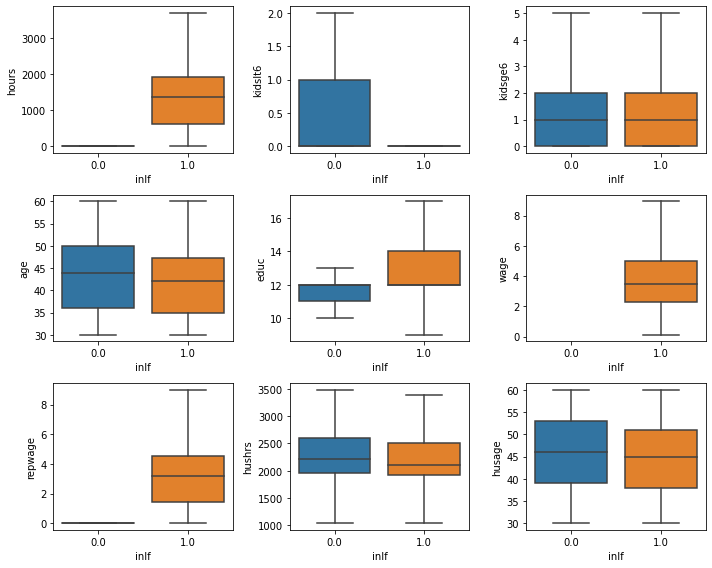

In [23]:
iter_cols = dt5_train.columns[range(1, 19)]
#
#
#
fig = plt.figure(num = 98, figsize = (10, 8))
for i in range(0, 9):
  ax1 = fig.add_subplot(3, 3, i + 1)
  _ = sns.boxplot(x = "inlf", y = iter_cols[i], data = dt5_train, ax = ax1, showfliers = False)
_ = plt.tight_layout()
plt.show()

In [24]:
tbl = pd.crosstab(index = dt5["city"], columns = dt5["inlf"])
print(tbl)

inlf  0.0  1.0
city          
0.0   115  154
1.0   210  274


In [25]:
dt5_tmp = dt5.copy()
dt5_tmp["inlf"] = np.where(dt5_tmp["inlf"] == 1, "In labor force", "Not in labor force")
#
dt5_tmp["city"] = np.where(dt5_tmp["city"] == 1, "Yes", "No")
#

In [26]:
tbl = pd.crosstab(index = dt5_tmp["city"], columns = dt5_tmp["inlf"])
print(tbl)

inlf  In labor force  Not in labor force
city                                    
No               154                 115
Yes              274                 210


In [27]:
print(tbl.T)

city                 No  Yes
inlf                        
In labor force      154  274
Not in labor force  115  210


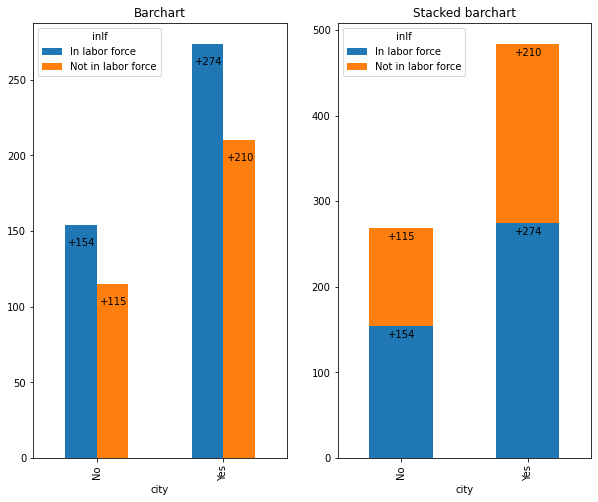

In [28]:
x_offset = -0.1
y_offset = -tbl.max().max() * 0.05
#
fig = plt.figure(figsize = (10, 8))
ax = tbl.plot.bar(ax = fig.add_subplot(1, 2, 1))
for p in ax.patches: # Add the numeric values to the bar chart
    b = p.get_bbox()
    val = "{:+.0f}".format(b.y1 + b.y0)        
    _ = ax.annotate(val, ((b.x0 + b.x1) / 2 + x_offset, b.y1 + y_offset))
_ = plt.title("Barchart")    
#    
ax = tbl.plot.bar(stacked = True, ax = fig.add_subplot(1, 2, 2))
for p in ax.patches: # Add the numeric values to the bar chart:
    b = p.get_bbox()
    val = "{:+.0f}".format(b.y1 - b.y0)        
    _ = ax.annotate(val, ((b.x0 + b.x1) / 2 + x_offset, b.y1 + y_offset))
_ = plt.title("Stacked barchart")      
plt.show()

In [29]:
# Can either specify in the function call:
# tbl_prop = pd.crosstab(index = dt5_tmp["city"], columns = dt5_tmp["inlf"], normalize = 'index')
# Or equivalently update an existing cross table:
tbl_prop = tbl.apply(lambda r: r / r.sum(), axis = 1)
print(tbl_prop)

inlf  In labor force  Not in labor force
city                                    
No          0.572491            0.427509
Yes         0.566116            0.433884


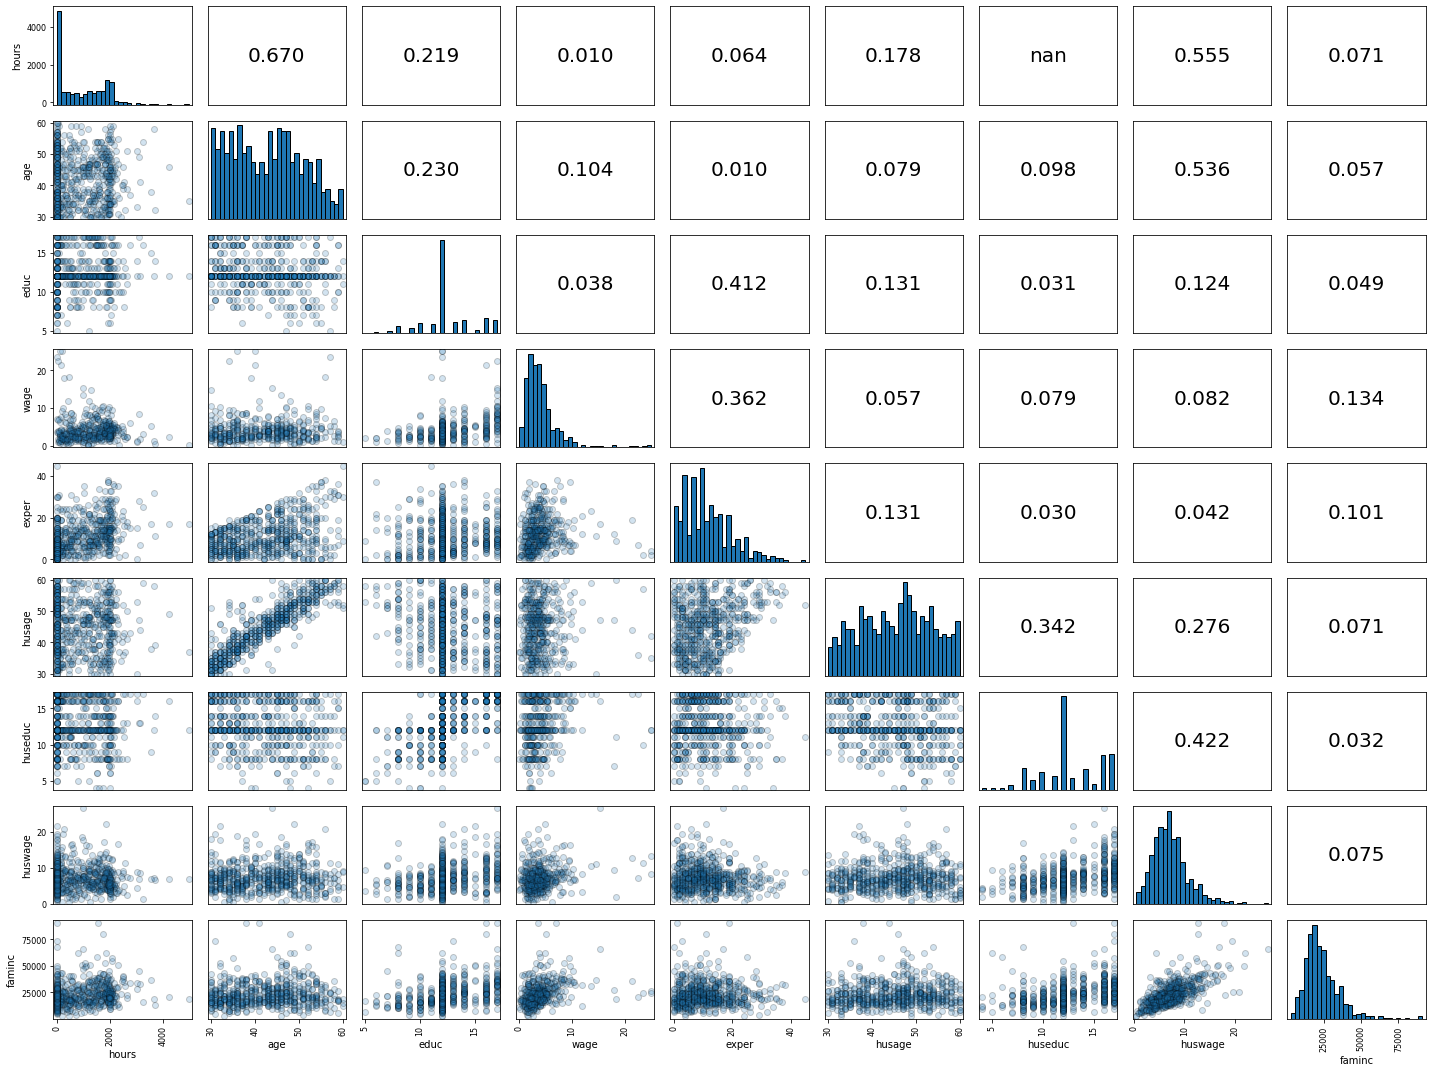

In [30]:
plt_cols = ["hours", "age", "educ", "wage", "exper", "husage", "huseduc", "huswage", "faminc"]
axes = pd.plotting.scatter_matrix(dt5_train[plt_cols], alpha = 0.2, figsize = (20, 15), marker = "o",
                           hist_kwds = dict(edgecolor = "black", linewidth = 1, bins = 30),
                           edgecolor = "black")
abs_corr = np.abs(dt5_train.corr().values)
for i, j in zip(*plt.np.triu_indices_from(axes, k = 1)): #triu - TRI-angle U-pper
    _ = axes[i, j].set_xlim((1.1, 1.12))
    _ = axes[i, j].set_ylim((1.1, 1.12))
    _ = axes[i, j].annotate("%.3f" %abs_corr[i,j], (0.5, 0.5), xycoords = 'axes fraction', 
                            ha = 'center', va = 'center', fontsize = 20)
_ = plt.tight_layout()
plt.show()

In [31]:
print(dt5_train[plt_cols].dropna().corr())

            hours       age      educ  ...   huseduc   huswage    faminc
hours    1.000000  0.054865 -0.064879  ... -0.085935 -0.110312  0.150738
age      0.054865  1.000000 -0.052171  ... -0.069319  0.088697  0.113923
educ    -0.064879 -0.052171  1.000000  ...  0.594343  0.303005  0.362328
wage    -0.097628  0.030394  0.341954  ...  0.166330  0.215886  0.302652
exper    0.299230  0.483646 -0.015206  ... -0.083213 -0.111674 -0.027489
husage   0.045849  0.894423 -0.069858  ... -0.113921  0.072388  0.086720
huseduc -0.085935 -0.069319  0.594343  ...  1.000000  0.396416  0.354684
huswage -0.110312  0.088697  0.303005  ...  0.396416  1.000000  0.668756
faminc   0.150738  0.113923  0.362328  ...  0.354684  0.668756  1.000000

[9 rows x 9 columns]


In [32]:
my_formula = "inlf ~ 1 + educ + exper + age + kidslt6 + kidsge6"
logit_glm  = smf.logit(my_formula, data = dt5_train).fit(disp = 0)
print(logit_glm.summary2().tables[1].round(5))

             Coef.  Std.Err.        z    P>|z|   [0.025   0.975]
Intercept  1.44243   1.00899  1.42958  0.15284 -0.53515  3.42001
educ       0.18468   0.04800  3.84757  0.00012  0.09060  0.27875
exper      0.12986   0.01691  7.67801  0.00000  0.09671  0.16302
age       -0.09074   0.01700 -5.33889  0.00000 -0.12405 -0.05743
kidslt6   -1.42174   0.22830 -6.22740  0.00000 -1.86921 -0.97427
kidsge6    0.07344   0.08762  0.83818  0.40193 -0.09829  0.24517


In [33]:
probit_glm  = smf.probit(my_formula, data = dt5_train).fit(disp = 0)# Sử dụng mô hình Probit
print(probit_glm.summary2().tables[1].round(5))

             Coef.  Std.Err.        z    P>|z|   [0.025   0.975]
Intercept  0.93705   0.58526  1.60109  0.10936 -0.21003  2.08413
educ       0.11016   0.02764  3.98617  0.00007  0.05600  0.16433
exper      0.07380   0.00903  8.16866  0.00000  0.05610  0.09151
age       -0.05496   0.00971 -5.66135  0.00000 -0.07399 -0.03594
kidslt6   -0.86249   0.13360 -6.45577  0.00000 -1.12434 -0.60064
kidsge6    0.03735   0.05020  0.74404  0.45685 -0.06104  0.13574


In [34]:
vif = pd.DataFrame() # Hệ số Vif để xem mô hình có hiện tượng đa cộng tuyến hay không (Thường là lớn hơn 8 là có đa cộng tuyến)
vif["VIF Factor"] = [oi.variance_inflation_factor(logit_glm.model.exog, i) for i in range(1, logit_glm.model.exog.shape[1])]
vif["Variable"]   = logit_glm.model.exog_names[1:]
print(vif)

   VIF Factor Variable
0    1.048660     educ
1    1.232963    exper
2    1.521952      age
3    1.242066  kidslt6
4    1.234228  kidsge6


In [35]:
logit_glm  = smf.logit("inlf ~ 1 + educ + np.power(educ, 2) + exper + np.power(exper, 2) + age + np.power(age, 2) + kidslt6 + np.power(kidslt6, 2) + kidsge6 + np.power(kidsge6, 2)", 
                      data = dt5_train).fit(disp = 0)
print(logit_glm.summary2().tables[1].round(5))

                        Coef.  Std.Err.        z    P>|z|   [0.025    0.975]
Intercept             2.37291   3.89189  0.60971  0.54206 -5.25505  10.00088
educ                 -0.21699   0.31343 -0.69231  0.48874 -0.83129   0.39731
np.power(educ, 2)     0.01618   0.01287  1.25699  0.20876 -0.00905   0.04141
exper                 0.20877   0.03959  5.27303  0.00000  0.13117   0.28638
np.power(exper, 2)   -0.00293   0.00128 -2.29261  0.02187 -0.00544  -0.00043
age                  -0.04097   0.16160 -0.25351  0.79987 -0.35769   0.27576
np.power(age, 2)     -0.00054   0.00187 -0.28590  0.77495 -0.00421   0.00314
kidslt6              -0.87533   0.62116 -1.40920  0.15878 -2.09278   0.34211
np.power(kidslt6, 2) -0.34784   0.36620 -0.94985  0.34219 -1.06557   0.36990
kidsge6               0.10136   0.22997  0.44074  0.65940 -0.34938   0.55210
np.power(kidsge6, 2) -0.00725   0.05133 -0.14126  0.88767 -0.10785   0.09335


In [36]:
# Hầu hết các hệ số ước lượng được không có ý nghĩa thống kê ..P>|z|>>0.05
# Vì vậy ta sẽ thêm lần lượt từng biến vào mô hình

In [37]:
logit_glm  = smf.logit("inlf ~ 1 + educ + np.power(educ, 2) + exper + age + kidslt6 + kidsge6", 
                      data = dt5_train).fit(disp = 0)
print(logit_glm.summary2().tables[1].round(5))

                     Coef.  Std.Err.        z    P>|z|   [0.025   0.975]
Intercept          3.57652   2.06186  1.73461  0.08281 -0.46465  7.61770
educ              -0.17722   0.30834 -0.57476  0.56546 -0.78155  0.42711
np.power(educ, 2)  0.01497   0.01265  1.18385  0.23647 -0.00982  0.03977
exper              0.12976   0.01686  7.69479  0.00000  0.09671  0.16281
age               -0.09132   0.01699 -5.37619  0.00000 -0.12461 -0.05803
kidslt6           -1.44724   0.23135 -6.25566  0.00000 -1.90068 -0.99381
kidsge6            0.08243   0.08795  0.93722  0.34864 -0.08996  0.25482


In [38]:
# Hệ số của educ và educ^2 đều không có ý nghĩa thống kê (coi như =0) ta loại educ^2 ra khỏi mô hình

In [39]:
logit_glm  = smf.logit("inlf ~ 1 + educ + exper + np.power(exper, 2) + age + kidslt6 + kidsge6", 
                      data = dt5_train).fit(disp = 0)
print(logit_glm.summary2().tables[1].round(5))

                      Coef.  Std.Err.        z    P>|z|   [0.025   0.975]
Intercept           1.17661   1.02513  1.14776  0.25107 -0.83262  3.18584
educ                0.17237   0.04844  3.55834  0.00037  0.07743  0.26731
exper               0.20720   0.03857  5.37172  0.00000  0.13160  0.28280
np.power(exper, 2) -0.00293   0.00124 -2.36144  0.01820 -0.00535 -0.00050
age                -0.08862   0.01729 -5.12677  0.00000 -0.12251 -0.05474
kidslt6            -1.41915   0.22989 -6.17327  0.00000 -1.86971 -0.96858
kidsge6             0.07470   0.08919  0.83749  0.40232 -0.10011  0.24951


In [40]:
# Hệ số của exper^2 có ý nghĩa thống kê p=0.018<0.05 nghĩa là số năm kinh nghiệm tăng rất nhiều cơ hội có việc làm 
# tuy nhiên nếu số năm kinh nghiệm quá cao tức là tuổi đã già nên cơ hội tham gia lực lượng 
# lao động lại giảm đi

In [41]:
logit_glm  = smf.logit("inlf ~ 1 + educ + exper + np.power(exper, 2) + age + kidslt6*kidsge6", 
                      data = dt5_train).fit(disp = 0)
print(logit_glm.summary2().tables[1].round(5))

                      Coef.  Std.Err.        z    P>|z|   [0.025   0.975]
Intercept           1.70098   1.04919  1.62123  0.10497 -0.35540  3.75735
educ                0.19791   0.05020  3.94197  0.00008  0.09951  0.29631
exper               0.21693   0.03877  5.59589  0.00000  0.14095  0.29291
np.power(exper, 2) -0.00318   0.00123 -2.57767  0.00995 -0.00560 -0.00076
age                -0.10395   0.01832 -5.67236  0.00000 -0.13986 -0.06803
kidslt6            -2.28803   0.37195 -6.15140  0.00000 -3.01705 -1.55902
kidsge6            -0.08289   0.09919 -0.83566  0.40334 -0.27729  0.11152
kidslt6:kidsge6     0.53630   0.16900  3.17341  0.00151  0.20507  0.86753


In [42]:
logit_glm  = smf.logit("inlf ~ 1 + educ + exper + np.power(exper, 2) + age + kidslt6*kidsge6 + np.power(kidslt6, 2) + np.power(kidsge6, 2)", 
                      data = dt5_train).fit(disp = 0)
print(logit_glm.summary2().tables[1].round(5))

                        Coef.  Std.Err.        z    P>|z|   [0.025   0.975]
Intercept             1.73274   1.09457  1.58304  0.11341 -0.41257  3.87806
educ                  0.19860   0.05039  3.94126  0.00008  0.09984  0.29736
exper                 0.21690   0.03890  5.57533  0.00000  0.14065  0.29315
np.power(exper, 2)   -0.00319   0.00124 -2.57792  0.00994 -0.00562 -0.00076
age                  -0.10446   0.01904 -5.48616  0.00000 -0.14178 -0.06714
kidslt6              -2.26474   0.74439 -3.04240  0.00235 -3.72372 -0.80576
kidsge6              -0.11724   0.22999 -0.50978  0.61021 -0.56801  0.33352
kidslt6:kidsge6       0.53807   0.17471  3.07977  0.00207  0.19564  0.88050
np.power(kidslt6, 2) -0.01828   0.37168 -0.04918  0.96078 -0.74677  0.71021
np.power(kidsge6, 2)  0.00829   0.04956  0.16729  0.86714 -0.08885  0.10543


In [43]:
# Mô hình cuối cùng sẽ là:

In [44]:
logit_glm  = smf.logit("inlf ~ 1 + educ + exper + np.power(exper, 2) + age + kidslt6*kidsge6", 
                      data = dt5_train).fit(disp = 0)
print(logit_glm.summary2().tables[1].round(5))

                      Coef.  Std.Err.        z    P>|z|   [0.025   0.975]
Intercept           1.70098   1.04919  1.62123  0.10497 -0.35540  3.75735
educ                0.19791   0.05020  3.94197  0.00008  0.09951  0.29631
exper               0.21693   0.03877  5.59589  0.00000  0.14095  0.29291
np.power(exper, 2) -0.00318   0.00123 -2.57767  0.00995 -0.00560 -0.00076
age                -0.10395   0.01832 -5.67236  0.00000 -0.13986 -0.06803
kidslt6            -2.28803   0.37195 -6.15140  0.00000 -3.01705 -1.55902
kidsge6            -0.08289   0.09919 -0.83566  0.40334 -0.27729  0.11152
kidslt6:kidsge6     0.53630   0.16900  3.17341  0.00151  0.20507  0.86753


In [45]:
# Hầu hết các hệ số góc đều có ý nghĩa thống kê nên ta tạm dùng mô hình này

In [46]:
# Chú ý: Khi ta viết x*y trong vế phải của mô hình thì trong mô hình sẽ có các biến x,y,xy

In [47]:
probit_glm  = smf.probit(logit_glm.model.formula, data = dt5_train).fit(disp = 0) # Mô hình Probit lấy công thức từ mô hình logit phía trên
print(probit_glm.summary2().tables[1].round(5))

                      Coef.  Std.Err.        z    P>|z|   [0.025   0.975]
Intercept           0.95926   0.60729  1.57958  0.11420 -0.23100  2.14953
educ                0.11640   0.02868  4.05878  0.00005  0.06019  0.17260
exper               0.12800   0.02195  5.83111  0.00000  0.08498  0.17102
np.power(exper, 2) -0.00188   0.00070 -2.69562  0.00703 -0.00324 -0.00051
age                -0.06025   0.01031 -5.84510  0.00000 -0.08045 -0.04005
kidslt6            -1.34130   0.20747 -6.46511  0.00000 -1.74793 -0.93467
kidsge6            -0.04653   0.05694 -0.81717  0.41383 -0.15813  0.06507
kidslt6:kidsge6     0.31497   0.09781  3.22010  0.00128  0.12326  0.50668


In [48]:
predicted_probs = logit_glm.predict(exog = dt5_train)
tmp_out = metrics.confusion_matrix(logit_glm.model.endog, np.where(predicted_probs >= 0.5, 1, 0))
print(tmp_out)

[[ 77  97]
 [ 42 386]]


In [49]:
print(dt5_train["inlf"].value_counts())

1.0    428
0.0    174
Name: inlf, dtype: int64


In [50]:
tmp_out = pd.DataFrame(tmp_out, columns = ["Predicted 0", "Predicted 1"],
                       index = ["Actual 0", "Actual 1"])
print(tmp_out)

          Predicted 0  Predicted 1
Actual 0           77           97
Actual 1           42          386


Chúng ta thấy rằng:

Chúng tôi đã dự đoán chính xác rằng 386 phụ nữ sẽ quay trở lại lực lượng lao động.
Hơn nữa, chúng tôi đã dự đoán chính xác rằng 77 phụ nữ sẽ không trở lại lực lượng lao động.
Mặt khác:

Chúng tôi đã dự đoán sai rằng 42 phụ nữ sẽ quay trở lại lực lượng lao động (họ thực sự không quay trở lại);
Chúng tôi đã dự đoán sai rằng 97 phụ nữ sẽ không trở lại lực lượng lao động (họ thực sự đã quay trở lại);

In [51]:
Nói chung, nếu chúng ta quan tâm đến việc xác định số lượng việc làm cần thiết cho phụ nữ, 
quay trở lại lực lượng lao động - 
sự khác biệt giữa số quay trở lại theo dự đoán và quay trở lại thực sự của lực lượng lao động là:

SyntaxError: ignored

In [ ]:
print(tmp_out.loc['Actual 1', 'Predicted 1'] + 
      tmp_out.loc['Actual 0', 'Predicted 1'] - 
      dt5_train["inlf"].value_counts()[1])

In [ ]:
Nói cách khác, chúng tôi đã đánh giá quá cao tổng lượng phụ nữ quay trở lại lực lượng lao động. 
Điều này sẽ có một số phức tạp:

có thể tạo ra quá nhiều vị trí việc làm trống;
quá nhiều nhân viên trường học / nhà trẻ sẽ được thuê (vì một số phụ nữ quyết định ở nhà chăm sóc con cái của họ);
nếu chúng tôi đưa ra bất kỳ quyết định nào khác liên quan đến lương thưởng / tiền lương dựa trên giá trị kỳ vọng của 
sự quay trở lại lực lượng lao động sẽ gây nhiều thiệt hại

In [ ]:
# Similar to optimalCutoff from R: https://github.com/selva86/InformationValue/blob/master/R/Main.R
thresholds = np.arange(start = np.max(predicted_probs), 
                       stop  = np.min(predicted_probs), step = -0.01)
#
misclasserror = []
for k in thresholds:
  y_pred = np.where(predicted_probs >= k, 1, 0)
  misclasserror.append(1 - metrics.accuracy_score(dt5_train['inlf'], y_pred))
#
optimalCutoff_logit = thresholds[misclasserror == np.min(misclasserror)][0]
print(optimalCutoff_logit)

In [ ]:
tmp_out_opt = metrics.confusion_matrix(logit_glm.model.endog, 
                                   np.where(predicted_probs >= optimalCutoff_logit, 1, 0))
tmp_out_opt = pd.DataFrame(tmp_out_opt, columns = ["Predicted 0", "Predicted 1"],
                       index = ["Actual 0", "Actual 1"])                                   
print(tmp_out_opt)

In [ ]:
print(tmp_out_opt.loc['Actual 1', 'Predicted 1'] + 
      tmp_out_opt.loc['Actual 0', 'Predicted 1'] - 
      dt5_train["inlf"].value_counts()[1])

In [ ]:
print((tmp_out_opt.loc['Actual 1', 'Predicted 1'] / tmp_out.loc['Actual 1', 'Predicted 1'] - 1) * 100)

In [ ]:
tmp_diagnostics = pd.DataFrame(
  metrics.precision_recall_fscore_support(logit_glm.model.endog, np.where(predicted_probs >= 0.5, 1, 0)),
  index = ["precision","recall", "fbeta_score", "support"])
print(tmp_diagnostics.iloc[0, 1])                      

In [ ]:
tmp_diagnostics

In [ ]:
tmp_diagnostics = pd.DataFrame(
  metrics.precision_recall_fscore_support(logit_glm.model.endog, np.where(predicted_probs >= optimalCutoff_logit, 1, 0)),
  index = ["precision","recall", "fbeta_score", "support"])
print(tmp_diagnostics.iloc[0, 1])  

In [ ]:
tmp_diagnostics

In [ ]:
predicted_probs = probit_glm.predict(exog = dt5_train)
tmp_out = metrics.confusion_matrix(probit_glm.model.endog, np.where(predicted_probs >= 0.5, 1, 0))
tmp_out = pd.DataFrame(tmp_out, columns = ["Predicted 0", "Predicted 1"],
                       index = ["Actual 0", "Actual 1"])
print(tmp_out)

In [ ]:
thresholds = np.arange(start = np.max(predicted_probs), 
                       stop  = np.min(predicted_probs), step = -0.01)
#
misclasserror = []
for k in thresholds:
  y_pred = np.where(predicted_probs >= k, 1, 0)
  misclasserror.append(1 - metrics.accuracy_score(dt5_train['inlf'], y_pred))
#
optimalCutoff_probit = thresholds[misclasserror == np.min(misclasserror)][0]
print(optimalCutoff_probit)

In [ ]:
tmp_out_opt = metrics.confusion_matrix(probit_glm.model.endog, 
                                   np.where(predicted_probs >= optimalCutoff_probit, 1, 0))
tmp_out_opt = pd.DataFrame(tmp_out_opt, columns = ["Predicted 0", "Predicted 1"],
                       index = ["Actual 0", "Actual 1"])                                   
print(tmp_out_opt)

In [ ]:
print(tmp_out_opt.loc['Actual 1', 'Predicted 1'] + 
      tmp_out_opt.loc['Actual 0', 'Predicted 1'] - 
      dt5_train["inlf"].value_counts()[1])

In [ ]:
tmp_diagnostics = pd.DataFrame(
  metrics.precision_recall_fscore_support(probit_glm.model.endog, np.where(predicted_probs >= optimalCutoff_probit, 1, 0)),
  index = ["precision","recall", "fbeta_score", "support"])
print(tmp_diagnostics.iloc[0, 1])   

In [ ]:
tmp_diagnostics

In [ ]:
thresholds = np.arange(start = 0.01, stop = 0.99 + 0.01, step = 0.01)
ppred = pd.DataFrame((logit_glm.predict(exog = dt5_train), 
                      probit_glm.predict(exog = dt5_train))).T
TPR = np.empty(shape = (0, 99))
FPR = np.empty(shape = (0, 99))
#
for j in range(0, len(ppred.columns)):
  tpr = np.array([])
  fpr = np.array([])
  for i in thresholds:
    tpr = np.hstack((tpr, 
                  metrics.recall_score(dt5_train[["inlf"]], np.where(ppred[j] >= i, 1, 0))))
    fpr = np.hstack((fpr, 
                  1 - metrics.precision_recall_fscore_support(dt5_train[["inlf"]], np.where(ppred[j] >= i, 1, 0))[1][0]))
  #
  TPR = np.vstack((TPR, tpr))
  FPR = np.vstack((FPR, fpr))
# 
TPR = pd.DataFrame(TPR).T
FPR = pd.DataFrame(FPR).T

In [ ]:
fig = plt.figure(figsize = (10, 8))
_ = plt.plot(thresholds, 
             thresholds, linestyle = "--", color = "red")
_ = plt.xlabel("FPR or (1 - Specificity)")
_ = plt.ylabel("TPR or Sensitivity")
_ = plt.title("ROC Curve")
for j in range(0, len(ppred.columns)):
  _ = plt.plot(FPR[j], TPR[j], linestyle = "-", 
               color = ["black", "blue", "darkorange"][j],
               label = ["logit", "probit", "random_coin_toss"][j])
#
_ = plt.legend(loc = "upper left")               
plt.show()

In [ ]:
#
#
fpr, tpr, thresholds = metrics.roc_curve(dt5_train[["inlf"]], ppred[0], pos_label = 1)
roc_auc = metrics.auc(fpr, tpr)
print(roc_auc)

In [ ]:
#
#
fpr, tpr, thresholds = metrics.roc_curve(dt5_train[["inlf"]], ppred[1], pos_label = 1)
roc_auc = metrics.auc(fpr, tpr)
print(roc_auc)

In [ ]:
def plotROC(fpr, tpr, thresholds): 
  #
  roc_auc = metrics.auc(fpr, tpr)
  #
  fig = plt.figure(figsize = (10, 8))
  plt.plot(fpr, tpr, linestyle = "-", color = "cornflowerblue")
  # Fill in the ROC curve
  plt.fill_between(fpr, tpr, 0, color = "cornflowerblue")
  # Add annotations
  plt.annotate(s = "AUROC: " + str(roc_auc.round(4)), xy = (0.3, 0.3), color = "white", fontsize = 25)
  for i in range(1, len(fpr))[::10]:
    _ = plt.annotate(s = thresholds[i].round(2), xy = (fpr[i], tpr[i]))
  #
  plt.xlabel("1-Specificity (FPR)", color = "cornflowerblue", fontsize = 25)
  plt.ylabel("Sensitivity (TPR)", color = "cornflowerblue", fontsize = 25)
  plt.title("ROC Curve", color = "cornflowerblue", fontsize = 25)
  # Setting the background color
  ax = fig.add_subplot(1, 1, 1) 
  ax.set_facecolor("lightgray")
  # Add grid
  plt.grid(True, zorder = 0, color = "white")
  # Make sure the grid is in the background
  plt.rcParams['axes.axisbelow'] = True
  plt.tight_layout()
  plt.show()
#

In [ ]:
fpr, tpr, thresholds = metrics.roc_curve(dt5_train[["inlf"]], ppred[0], pos_label = 1)
plotROC(fpr, tpr, thresholds)

In [ ]:
fpr, tpr, thresholds = metrics.roc_curve(dt5_train[["inlf"]], ppred[1], pos_label = 1)
plotROC(fpr, tpr, thresholds)